In [1]:
import numpy as np
import pandas as pd
import pymc as pm
import arviz as az
import patsy
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from pymc.variational.callbacks import CheckParametersConvergence

RANDOM_SEED = 42
rng = np.random.default_rng(RANDOM_SEED)

DATA_DIR    = Path('../data/processed')
RESULTS_DIR = Path('../results')
FIGURES_DIR = Path('../figures')
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

print(f"PyMC version:  {pm.__version__}")
print(f"ArviZ version: {az.__version__}")
print(f"patsy version: {patsy.__version__}")

# Pre-check: Pass 1 results need to be on disk for the comparison cell.
pass1_trace_path = RESULTS_DIR / 'multirace_pass1_advi_trace.nc'
if pass1_trace_path.exists():
    print(f"Pass 1 trace found: {pass1_trace_path}")
else:
    print(f"WARNING: Pass 1 trace not found at {pass1_trace_path}")
    print("Run notebook 02 first, or the comparison cell will be skipped.")


PyMC version:  6.0.0
ArviZ version: 1.1.0
patsy version: 1.0.1
Pass 1 trace found: ../results/multirace_pass1_advi_trace.nc


In [2]:
# ---- Load data (same as notebook 02) ----
MIN_DRY_LAPS_PER_RACE = 30

raw_files = sorted(Path(DATA_DIR).glob('*.parquet'))
frames, seen = [], set()
for path in raw_files:
    stem = path.stem
    try:
        year_str, location = stem.split('_', 1)
        year = int(year_str)
    except (ValueError, TypeError):
        continue
    df_ = pd.read_parquet(path)
    if 'circuit' not in df_.columns:
        df_['circuit'] = location
    circuit = df_['circuit'].iloc[0]
    if (year, circuit) in seen:
        continue
    df_['race_id'] = f"{year}_{location}"
    df_['season'] = year
    seen.add((year, circuit))
    frames.append(df_)

raw = pd.concat(frames, ignore_index=True)
raw['Team'] = raw['Team'].replace({'RB': 'Racing Bulls'})

df = raw[(raw['anomaly_flag'] == 'normal')
         & (raw['compound_condition'] == 'DRY')].copy().reset_index(drop=True)

race_counts = df.groupby('race_id').size()
sparse_races = race_counts[race_counts < MIN_DRY_LAPS_PER_RACE].index.tolist()
if sparse_races:
    df = df[~df['race_id'].isin(sparse_races)].reset_index(drop=True)

print(f"Pass 2 dataset: {len(df):,} laps from {df['race_id'].nunique()} races")


Pass 2 dataset: 42,491 laps from 47 races


In [3]:
# ---- Build indices + spline basis ----
# Pass 2 adds: stint_idx (for eta_stint) and a B-spline basis matrix on
# lap_in_stint (for compound-specific non-linear tyre wear).

race_cat        = pd.Categorical(df['race_id'])
driver_cat      = pd.Categorical(df['Driver'])
constructor_cat = pd.Categorical(df['Team'])
compound_cat    = pd.Categorical(df['Compound'])
stint_cat       = pd.Categorical(df['stint_id'])

df['race_idx']        = race_cat.codes
df['driver_idx']      = driver_cat.codes
df['constructor_idx'] = constructor_cat.codes
df['compound_idx']    = compound_cat.codes
df['stint_idx']       = stint_cat.codes

race_names        = race_cat.categories.values
driver_names      = driver_cat.categories.values
constructor_names = constructor_cat.categories.values
compound_names    = compound_cat.categories.values

race_idx        = df['race_idx'].values
driver_idx      = df['driver_idx'].values
constructor_idx = df['constructor_idx'].values
compound_idx    = df['compound_idx'].values
stint_idx       = df['stint_idx'].values

lap_in_stint = df['lap_in_stint'].values.astype(float)
y = df['lap_time_fuel_corrected'].values

n_races        = len(race_names)
n_drivers      = len(driver_names)
n_constructors = len(constructor_names)
n_compounds    = len(compound_names)
n_stints       = stint_cat.categories.size

# B-spline basis on lap_in_stint. df=5 cubic gives flexible-but-stable shape:
# can capture cold-tyre ramp-up, plateau, and degradation tail without overfitting.
# Center columns so tyre_intercept stays interpretable as fresh-tyre pace.
B_raw = np.asarray(
    patsy.dmatrix('bs(x, df=5, degree=3, include_intercept=False)',
                  {'x': lap_in_stint}, return_type='matrix')
)
B = B_raw - B_raw.mean(axis=0, keepdims=True)
n_basis = B.shape[1]

print(f"Model dimensions:")
print(f"  Races:        {n_races}")
print(f"  Drivers:      {n_drivers}")
print(f"  Constructors: {n_constructors}")
print(f"  Compounds:    {n_compounds}")
print(f"  Stints:       {n_stints:,}")
print(f"  Spline basis: {n_basis} columns ({B.shape[0]:,} rows)")
print(f"  Observations: {len(y):,}")


Model dimensions:
  Races:        47
  Drivers:      27
  Constructors: 10
  Compounds:    3
  Stints:       2,125
  Spline basis: 6 columns (42,491 rows)
  Observations: 42,491


In [4]:
# ---- Pass 2 model spec ----
# Pass 2 = Pass 1 + three structural additions:
#   1. Constructor-race deviations (delta_cr) - tighter prior than original (0.3 vs 0.5)
#   2. Stint random effects (eta_stint)
#   3. Spline tyre wear (replaces quadratic)
#
# Note: non-centered Normal parameterization for delta_cr and eta_stint matches
# the design memo; ADVI handles these funnels OK and they're not strict zero-sum.

with pm.Model() as model:
    # ---- Hyperpriors ----
    sigma_race        = pm.HalfNormal('sigma_race',        sigma=15.0)
    sigma_driver      = pm.HalfNormal('sigma_driver',      sigma=1.0)
    sigma_constructor = pm.HalfNormal('sigma_constructor', sigma=1.0)
    sigma_delta       = pm.HalfNormal('sigma_delta',       sigma=0.3)
    sigma_stint       = pm.HalfNormal('sigma_stint',       sigma=0.5)

    # ---- Race intercept (carries the baseline) ----
    race_intercept = pm.Normal('race_intercept', mu=float(y.mean()),
                               sigma=sigma_race, shape=n_races)

    # ---- Constant driver and constructor effects ----
    alpha_d = pm.ZeroSumNormal('alpha_d', sigma=sigma_driver,      shape=n_drivers)
    beta_c  = pm.ZeroSumNormal('beta_c',  sigma=sigma_constructor, shape=n_constructors)

    # ---- NEW: Constructor-race deviations (non-centered) ----
    delta_cr_raw = pm.Normal('delta_cr_raw', mu=0, sigma=1,
                             shape=(n_constructors, n_races))
    delta_cr     = pm.Deterministic('delta_cr', delta_cr_raw * sigma_delta)

    # ---- NEW: Stint random effects (non-centered) ----
    eta_stint_raw = pm.Normal('eta_stint_raw', mu=0, sigma=1, shape=n_stints)
    eta_stint     = pm.Deterministic('eta_stint', eta_stint_raw * sigma_stint)

    # ---- Compound baseline (kept from Pass 1) ----
    tyre_intercept = pm.ZeroSumNormal('tyre_intercept', sigma=0.5, shape=n_compounds)

    # ---- NEW: Spline tyre wear per compound (replaces tyre_linear + tyre_quad) ----
    spline_coefs = pm.Normal('spline_coefs', mu=0, sigma=0.5,
                             shape=(n_compounds, n_basis))
    # Per-observation tyre wear: row of B times that observation's compound's coefs
    tyre_wear = (B * spline_coefs[compound_idx]).sum(axis=1)

    # ---- Expected lap time ----
    mu = (race_intercept[race_idx]
          + alpha_d[driver_idx]
          + beta_c[constructor_idx]
          + delta_cr[constructor_idx, race_idx]
          + eta_stint[stint_idx]
          + tyre_intercept[compound_idx]
          + tyre_wear)

    sigma = pm.HalfNormal('sigma', sigma=2.0)
    y_obs = pm.Normal('y_obs', mu=mu, sigma=sigma, observed=y)

free_est = (n_races + (n_drivers - 1) + (n_constructors - 1)
            + n_constructors * n_races
            + n_stints
            + (n_compounds - 1) + n_compounds * n_basis
            + 6)
print(f"Pass 2 model specified. Approx free parameters: {free_est:,}")
print(f"  (+ {n_constructors * n_races:,} delta_cr, + {n_stints:,} eta_stint, "
      f"+ {n_compounds * n_basis} spline coefs vs Pass 1)")


Pass 2 model specified. Approx free parameters: 2,703
  (+ 470 delta_cr, + 2,125 eta_stint, + 18 spline coefs vs Pass 1)


<<!! BUG IN FGRAPH.REPLACE OR A LISTENER !!>> <class 'TypeError'> The type of the replacement (Vector(float64, shape=(27,))) must be compatible with the type of the original Variable (Vector(float64, shape=(10,))). inline_ofg_expansion
Rewrite failure due to: inline_ofg_expansion
node: ZeroSumNormal{inline=True}(RNG(<Generator(PCG64) at 0x12194D700>), [], ExpandDims{axis=0}.0, ExpandDims{axis=0}.0)
TRACEBACK:
Traceback (most recent call last):
  File "/Users/prabhatm/Library/Python/3.14/lib/python/site-packages/pytensor/graph/rewriting/basic.py", line 1968, in process_node
    fgraph.replace_all_validate_remove(
    ~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~~^
        repl_pairs, reason=node_rewriter, remove=remove
        ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
    )
    ^
  File "/Users/prabhatm/Library/Python/3.14/lib/python/site-packages/pytensor/graph/features.py", line 842, in replace_all_validate_remove
    chk = fgraph.replace_all_validate(replacements, reason=reason, **kwargs)


Output()

Finished [100%]: Average Loss = 54,503



PASS 2 ADVI FIT
Elapsed:          12.0 min
Iterations run:   100,000  (cap: 100,000)
Final ELBO loss:  54484.1


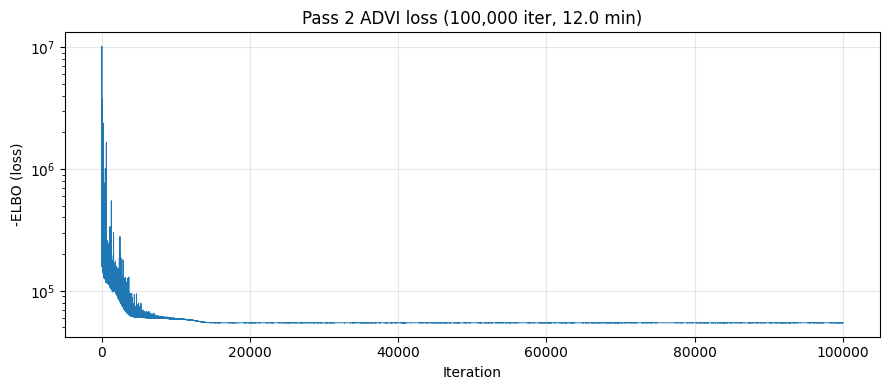

In [5]:
# ---- Pass 2 ADVI fit ----
import time

ADVI_ITER = 100_000
t0 = time.time()
with model:
    approx = pm.fit(
        n=ADVI_ITER,
        method='advi',
        obj_optimizer=pm.adam(learning_rate=0.01),
        random_seed=RANDOM_SEED,
        callbacks=[CheckParametersConvergence(diff='absolute', tolerance=0.01)],
        progressbar=True,
    )
    advi_trace = approx.sample(2000)
advi_elapsed = time.time() - t0

advi_trace.to_netcdf(RESULTS_DIR / 'multirace_pass2_advi_trace.nc')

loss = np.asarray(approx.hist)
n_actual_iter = len(loss)
print()
print('=' * 72)
print('PASS 2 ADVI FIT')
print('=' * 72)
print(f"Elapsed:          {advi_elapsed/60:.1f} min")
print(f"Iterations run:   {n_actual_iter:,}  (cap: {ADVI_ITER:,})")
print(f"Final ELBO loss:  {loss[-1]:.1f}")

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(loss, lw=0.7, color='#1f77b4')
ax.set_xlabel('Iteration')
ax.set_ylabel('-ELBO (loss)')
ax.set_title(f'Pass 2 ADVI loss ({n_actual_iter:,} iter, {advi_elapsed/60:.1f} min)')
ax.set_yscale('log')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '20_pass2_advi_elbo.png', dpi=120, bbox_inches='tight')
plt.show()


In [6]:
from datetime import datetime, timezone

trace = advi_trace

# Driver rankings
driver_means = trace.posterior['alpha_d'].mean(dim=['chain', 'draw']).values
driver_hdi   = az.hdi(trace, var_names=['alpha_d'], prob=0.95)['alpha_d'].values
driver_p2 = pd.DataFrame({
    'driver': driver_names, 'effect': driver_means,
    'hdi_low': driver_hdi[:, 0], 'hdi_high': driver_hdi[:, 1],
    'excludes_zero': (driver_hdi[:, 0] > 0) | (driver_hdi[:, 1] < 0),
}).sort_values('effect').reset_index(drop=True)

print("PASS 2 DRIVER EFFECTS:")
for _, row in driver_p2.iterrows():
    marker = ' *' if row['excludes_zero'] else '  '
    print(f"  {row['driver']:5s}  {row['effect']:+.3f}s "
          f"[95% HDI: {row['hdi_low']:+.3f}, {row['hdi_high']:+.3f}]{marker}")

# Constructor rankings
cons_means = trace.posterior['beta_c'].mean(dim=['chain', 'draw']).values
cons_hdi   = az.hdi(trace, var_names=['beta_c'], prob=0.95)['beta_c'].values
cons_p2 = pd.DataFrame({
    'constructor': constructor_names, 'effect': cons_means,
    'hdi_low': cons_hdi[:, 0], 'hdi_high': cons_hdi[:, 1],
    'excludes_zero': (cons_hdi[:, 0] > 0) | (cons_hdi[:, 1] < 0),
}).sort_values('effect').reset_index(drop=True)

print("\nPASS 2 CONSTRUCTOR BASELINE EFFECTS:")
for _, row in cons_p2.iterrows():
    marker = ' *' if row['excludes_zero'] else '  '
    print(f"  {row['constructor']:25s}  {row['effect']:+.3f}s "
          f"[95% HDI: {row['hdi_low']:+.3f}, {row['hdi_high']:+.3f}]{marker}")

# Variance decomposition (now 6 components)
sigma_race_m  = float(trace.posterior['sigma_race'].mean().item())
sigma_d       = float(trace.posterior['sigma_driver'].mean().item())
sigma_c       = float(trace.posterior['sigma_constructor'].mean().item())
sigma_delta_m = float(trace.posterior['sigma_delta'].mean().item())
sigma_stint_m = float(trace.posterior['sigma_stint'].mean().item())
sigma_r       = float(trace.posterior['sigma'].mean().item())

total_var = (sigma_race_m**2 + sigma_d**2 + sigma_c**2
             + sigma_delta_m**2 + sigma_stint_m**2 + sigma_r**2)
cond_var = (sigma_d**2 + sigma_c**2 + sigma_delta_m**2 + sigma_stint_m**2 + sigma_r**2)

print("\nPASS 2 VARIANCE DECOMPOSITION (conditional on race intercept):")
for name, s in [('Driver', sigma_d), ('Constructor', sigma_c),
                ('Constructor-race dev', sigma_delta_m), ('Stint', sigma_stint_m),
                ('Residual', sigma_r)]:
    print(f"  {name:25s}  sigma = {s:6.3f}s   share = {100*s**2/cond_var:5.1f}%")

# Constructor-race deviation matrix
delta_means = trace.posterior['delta_cr'].mean(dim=['chain', 'draw']).values
delta_df = pd.DataFrame(delta_means, index=constructor_names, columns=race_names)
delta_df.to_csv(RESULTS_DIR / 'multirace_pass2_constructor_race_deviations.csv')

# Save
driver_p2.to_csv(RESULTS_DIR / 'multirace_pass2_driver_effects.csv', index=False)
cons_p2.to_csv(RESULTS_DIR / 'multirace_pass2_constructor_effects.csv', index=False)

with open(RESULTS_DIR / 'multirace_pass2_summary.md', 'w') as f:
    f.write("# Multi-Race Foundational Regression - Pass 2 (ADVI)\n\n")
    f.write("## Provenance\n")
    f.write(f"- Generated:    {datetime.now(timezone.utc).isoformat(timespec='seconds')}\n")
    f.write(f"- Inference:    ADVI mean-field\n")
    f.write(f"- ADVI iter:    {n_actual_iter:,}\n")
    f.write(f"- Elapsed:      {advi_elapsed/60:.1f} min\n")
    f.write(f"- Races:        {n_races}\n")
    f.write(f"- Stints:       {n_stints:,}\n")
    f.write(f"- Observations: {len(y):,}\n\n")
    f.write("## Pass 2 vs Pass 1 additions\n")
    f.write("- Constructor-race deviations delta_cr (sigma_delta prior 0.3)\n")
    f.write("- Stint random effects eta_stint (sigma_stint prior 0.5)\n")
    f.write("- Spline tyre wear (B-spline df=5, degree=3) replacing linear + quadratic\n\n")

    f.write("## Variance Decomposition (conditional on race)\n")
    for name, s in [('Driver', sigma_d), ('Constructor', sigma_c),
                    ('Constructor-race dev', sigma_delta_m), ('Stint', sigma_stint_m),
                    ('Residual', sigma_r)]:
        f.write(f"- {name}: {s:.3f}s ({100*s**2/cond_var:.1f}%)\n")

    n_excl = int(driver_p2['excludes_zero'].sum())
    f.write(f"\n## Driver effects (full ranking)\n")
    f.write(f"_{n_excl}/{n_drivers} drivers have 95% HDI excluding zero._\n\n")
    for _, row in driver_p2.iterrows():
        marker = ' **' if row['excludes_zero'] else ''
        f.write(f"- {row['driver']}: {row['effect']:+.3f}s "
                f"[{row['hdi_low']:+.3f}, {row['hdi_high']:+.3f}]{marker}\n")

    f.write(f"\n## Constructor baseline effects\n")
    for _, row in cons_p2.iterrows():
        marker = ' **' if row['excludes_zero'] else ''
        f.write(f"- {row['constructor']}: {row['effect']:+.3f}s "
                f"[{row['hdi_low']:+.3f}, {row['hdi_high']:+.3f}]{marker}\n")

print(f"\nResults saved to {RESULTS_DIR}/")


PASS 2 DRIVER EFFECTS:
  VER    -0.740s [95% HDI: -0.773, -0.710] *
  SAI    -0.289s [95% HDI: -0.321, -0.254] *
  GAS    -0.266s [95% HDI: -0.302, -0.229] *
  PER    -0.178s [95% HDI: -0.229, -0.135] *
  HUL    -0.164s [95% HDI: -0.203, -0.124] *
  NOR    -0.164s [95% HDI: -0.192, -0.131] *
  LEC    -0.156s [95% HDI: -0.191, -0.123] *
  ALO    -0.085s [95% HDI: -0.122, -0.049] *
  DOO    -0.052s [95% HDI: -0.134, +0.032]  
  ALB    -0.050s [95% HDI: -0.085, -0.015] *
  BOR    -0.044s [95% HDI: -0.090, +0.001]  
  PIA    -0.027s [95% HDI: -0.063, +0.004]  
  RUS    -0.010s [95% HDI: -0.043, +0.022]  
  OCO    +0.002s [95% HDI: -0.036, +0.040]  
  COL    +0.020s [95% HDI: -0.018, +0.061]  
  BEA    +0.028s [95% HDI: -0.025, +0.080]  
  HAM    +0.033s [95% HDI: +0.000, +0.062] *
  HAD    +0.037s [95% HDI: -0.008, +0.084]  
  STR    +0.143s [95% HDI: +0.108, +0.179] *
  MAG    +0.160s [95% HDI: +0.116, +0.205] *
  BOT    +0.176s [95% HDI: +0.134, +0.218] *
  LAW    +0.227s [95% HDI: +0.18

In [7]:
# ---- Pass 1 vs Pass 2 comparison ----
# Loads Pass 1 CSVs from disk and compares to Pass 2 in-memory.
from scipy.stats import spearmanr

p1_driver_path = RESULTS_DIR / 'multirace_pass1_driver_effects.csv'
p1_cons_path   = RESULTS_DIR / 'multirace_pass1_constructor_effects.csv'

if not (p1_driver_path.exists() and p1_cons_path.exists()):
    print(f"Pass 1 results not on disk; run notebook 02 first.")
else:
    p1_driver = pd.read_csv(p1_driver_path)
    p1_cons   = pd.read_csv(p1_cons_path)

    # Align by driver name
    driver_compare = pd.merge(
        p1_driver[['driver', 'effect', 'hdi_low', 'hdi_high']]
            .rename(columns={'effect': 'p1_effect', 'hdi_low': 'p1_low', 'hdi_high': 'p1_high'}),
        driver_p2[['driver', 'effect', 'hdi_low', 'hdi_high']]
            .rename(columns={'effect': 'p2_effect', 'hdi_low': 'p2_low', 'hdi_high': 'p2_high'}),
        on='driver', how='inner',
    )
    driver_compare['diff']  = driver_compare['p2_effect'] - driver_compare['p1_effect']
    driver_compare['p1_w']  = driver_compare['p1_high'] - driver_compare['p1_low']
    driver_compare['p2_w']  = driver_compare['p2_high'] - driver_compare['p2_low']

    cons_compare = pd.merge(
        p1_cons[['constructor', 'effect']].rename(columns={'effect': 'p1_effect'}),
        cons_p2[['constructor', 'effect']].rename(columns={'effect': 'p2_effect'}),
        on='constructor', how='inner',
    )
    cons_compare['diff'] = cons_compare['p2_effect'] - cons_compare['p1_effect']

    sp_d, _   = spearmanr(driver_compare['p1_effect'], driver_compare['p2_effect'])
    sp_c, _   = spearmanr(cons_compare['p1_effect'], cons_compare['p2_effect'])
    rmse_d    = float(np.sqrt(np.mean(driver_compare['diff']**2)))
    rmse_c    = float(np.sqrt(np.mean(cons_compare['diff']**2)))
    mean_p1_w = float(driver_compare['p1_w'].mean())
    mean_p2_w = float(driver_compare['p2_w'].mean())

    print('=' * 72)
    print('PASS 1 vs PASS 2 COMPARISON')
    print('=' * 72)
    print(f"Driver Spearman:           {sp_d:.3f}")
    print(f"Driver RMSE (P2 - P1):     {rmse_d:.4f}s")
    print(f"Constructor Spearman:      {sp_c:.3f}")
    print(f"Constructor RMSE:          {rmse_c:.4f}s")
    print(f"Driver HDI width Pass 1:   {mean_p1_w:.3f}s (mean)")
    print(f"Driver HDI width Pass 2:   {mean_p2_w:.3f}s (mean)")
    print(f"HDI tightening:            {(1 - mean_p2_w/mean_p1_w)*100:+.1f}%")
    print()
    print("Per-driver effects:")
    print(driver_compare[['driver','p1_effect','p2_effect','diff','p1_w','p2_w']]
          .sort_values('p2_effect').to_string(index=False))
    print()
    print("Per-constructor:")
    print(cons_compare.sort_values('p2_effect').to_string(index=False))

    driver_compare.to_csv(RESULTS_DIR / 'pass1_vs_pass2_drivers.csv', index=False)
    cons_compare.to_csv(RESULTS_DIR / 'pass1_vs_pass2_constructors.csv', index=False)


PASS 1 vs PASS 2 COMPARISON
Driver Spearman:           0.925
Driver RMSE (P2 - P1):     0.1035s
Constructor Spearman:      0.988
Constructor RMSE:          0.0922s
Driver HDI width Pass 1:   0.099s (mean)
Driver HDI width Pass 2:   0.083s (mean)
HDI tightening:            +16.5%

Per-driver effects:
driver  p1_effect  p2_effect      diff     p1_w     p2_w
   VER  -0.852098  -0.739940  0.112158 0.076325 0.062789
   SAI  -0.232836  -0.289366 -0.056530 0.074261 0.066827
   GAS  -0.307246  -0.265755  0.041491 0.092377 0.072940
   PER  -0.311771  -0.178098  0.133673 0.115039 0.093102
   HUL  -0.202227  -0.163636  0.038591 0.086300 0.079076
   NOR  -0.194160  -0.163543  0.030617 0.073403 0.061061
   LEC  -0.207327  -0.155908  0.051418 0.080424 0.067229
   ALO  -0.066203  -0.085308 -0.019105 0.082212 0.073026
   DOO  -0.174218  -0.052157  0.122061 0.226757 0.166326
   ALB  -0.036552  -0.050079 -0.013527 0.081512 0.069971
   BOR  -0.084937  -0.043813  0.041124 0.115080 0.091088
   PIA  -0.0355

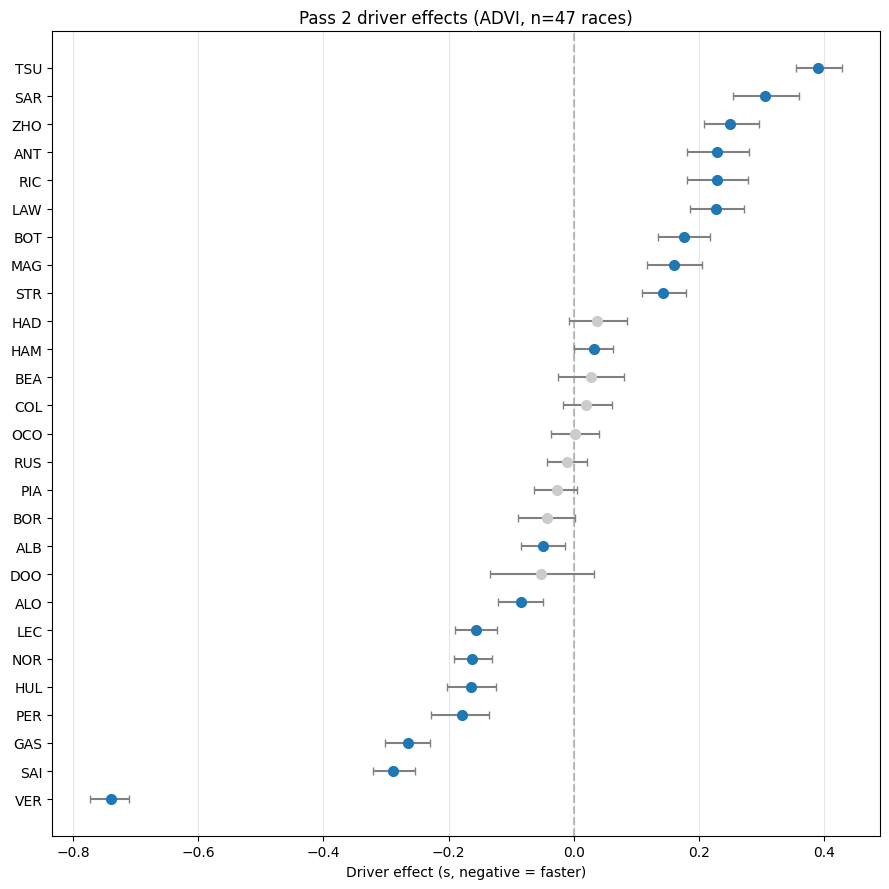

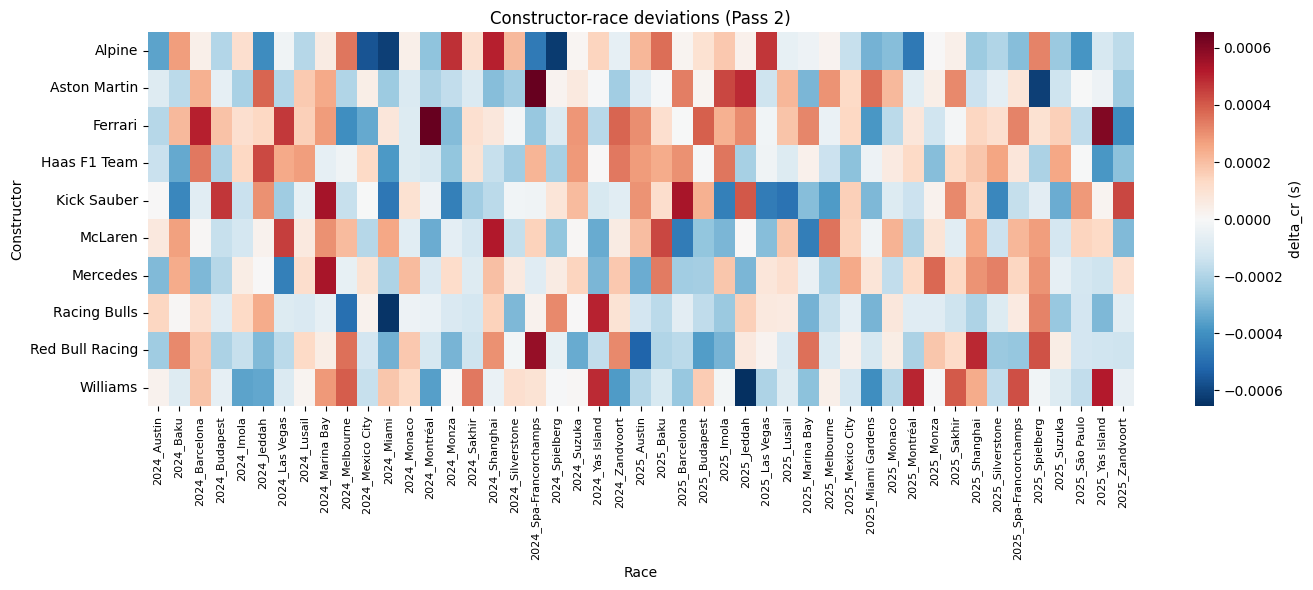

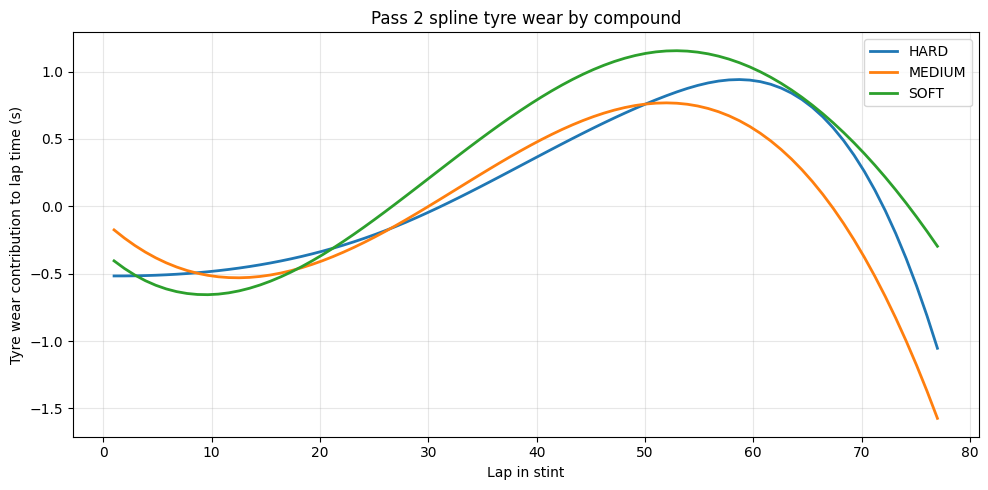

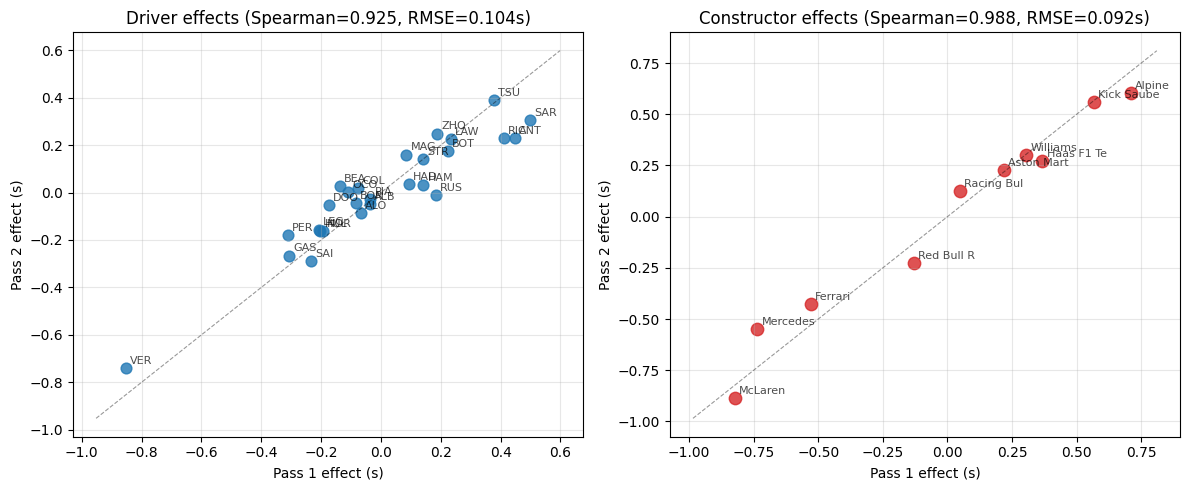

In [8]:
# ---- Plots ----

# Pass 2 driver forest plot
fig, ax = plt.subplots(figsize=(9, 9))
sd = driver_p2.sort_values('effect', ascending=True)
positions = np.arange(len(sd))
colors = np.where(sd['excludes_zero'], '#1f77b4', '#cccccc')
ax.errorbar(sd['effect'], positions,
            xerr=[sd['effect'] - sd['hdi_low'], sd['hdi_high'] - sd['effect']],
            fmt='o', markersize=6, capsize=3, ecolor='gray')
for i, c in enumerate(colors):
    ax.plot(sd['effect'].iloc[i], i, 'o', color=c, markersize=7, zorder=3)
ax.axvline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_yticks(positions)
ax.set_yticklabels(sd['driver'])
ax.set_xlabel('Driver effect (s, negative = faster)')
ax.set_title(f'Pass 2 driver effects (ADVI, n={n_races} races)')
ax.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '21_pass2_driver_effects.png', dpi=120, bbox_inches='tight')
plt.show()

# Constructor-race deviation heatmap (the new Pass 2 artifact)
fig, ax = plt.subplots(figsize=(14, 6))
sns.heatmap(delta_df, cmap='RdBu_r', center=0, ax=ax, cbar_kws={'label': 'delta_cr (s)'})
ax.set_title('Constructor-race deviations (Pass 2)')
ax.set_xlabel('Race')
ax.set_ylabel('Constructor')
plt.xticks(rotation=90, fontsize=8)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '22_pass2_constructor_race_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()

# Spline tyre wear curves per compound
fig, ax = plt.subplots(figsize=(10, 5))
spline_means = trace.posterior['spline_coefs'].mean(dim=['chain', 'draw']).values
x_grid = np.linspace(1, lap_in_stint.max(), 80)
B_grid = np.asarray(patsy.dmatrix('bs(x, df=5, degree=3, include_intercept=False)',
                                   {'x': x_grid}, return_type='matrix'))
B_grid_c = B_grid - B_raw.mean(axis=0, keepdims=True)
ti_means = trace.posterior['tyre_intercept'].mean(dim=['chain', 'draw']).values
for i, compound in enumerate(compound_names):
    curve = (B_grid_c * spline_means[i]).sum(axis=1) + ti_means[i]
    ax.plot(x_grid, curve, lw=2, label=f'{compound}')
ax.set_xlabel('Lap in stint')
ax.set_ylabel('Tyre wear contribution to lap time (s)')
ax.set_title('Pass 2 spline tyre wear by compound')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(FIGURES_DIR / '23_pass2_spline_tyre_wear.png', dpi=120, bbox_inches='tight')
plt.show()

# Pass 1 vs Pass 2 scatter (if comparison was run)
if 'driver_compare' in globals():
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    axes[0].scatter(driver_compare['p1_effect'], driver_compare['p2_effect'], s=60, alpha=0.8)
    lim = [min(driver_compare['p1_effect'].min(), driver_compare['p2_effect'].min()) - 0.1,
           max(driver_compare['p1_effect'].max(), driver_compare['p2_effect'].max()) + 0.1]
    axes[0].plot(lim, lim, 'k--', alpha=0.4, lw=0.8)
    axes[0].set_xlabel('Pass 1 effect (s)')
    axes[0].set_ylabel('Pass 2 effect (s)')
    axes[0].set_title(f'Driver effects (Spearman={sp_d:.3f}, RMSE={rmse_d:.3f}s)')
    axes[0].grid(True, alpha=0.3)
    for _, row in driver_compare.iterrows():
        axes[0].annotate(row['driver'], (row['p1_effect'], row['p2_effect']),
                         fontsize=8, alpha=0.7, xytext=(3, 3), textcoords='offset points')

    axes[1].scatter(cons_compare['p1_effect'], cons_compare['p2_effect'], s=80, alpha=0.8, color='#d62728')
    lim = [min(cons_compare['p1_effect'].min(), cons_compare['p2_effect'].min()) - 0.1,
           max(cons_compare['p1_effect'].max(), cons_compare['p2_effect'].max()) + 0.1]
    axes[1].plot(lim, lim, 'k--', alpha=0.4, lw=0.8)
    axes[1].set_xlabel('Pass 1 effect (s)')
    axes[1].set_ylabel('Pass 2 effect (s)')
    axes[1].set_title(f'Constructor effects (Spearman={sp_c:.3f}, RMSE={rmse_c:.3f}s)')
    axes[1].grid(True, alpha=0.3)
    for _, row in cons_compare.iterrows():
        axes[1].annotate(row['constructor'][:10], (row['p1_effect'], row['p2_effect']),
                         fontsize=8, alpha=0.7, xytext=(3, 3), textcoords='offset points')
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / '24_pass1_vs_pass2.png', dpi=120, bbox_inches='tight')
    plt.show()
